In [1]:
import scanpy as sc
import anndata
from anndata import AnnData

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

adata_astro = sc.read_h5ad("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/p28_scvi_astro_250428.h5ad")

In [2]:
from __future__ import annotations

import scanpy as sc
from matplotlib.pyplot import rc_context

In [3]:
sc.set_figure_params(dpi=100, color_map="viridis_r")
sc.settings.verbosity = 0
sc.logging.print_header()
%matplotlib inline

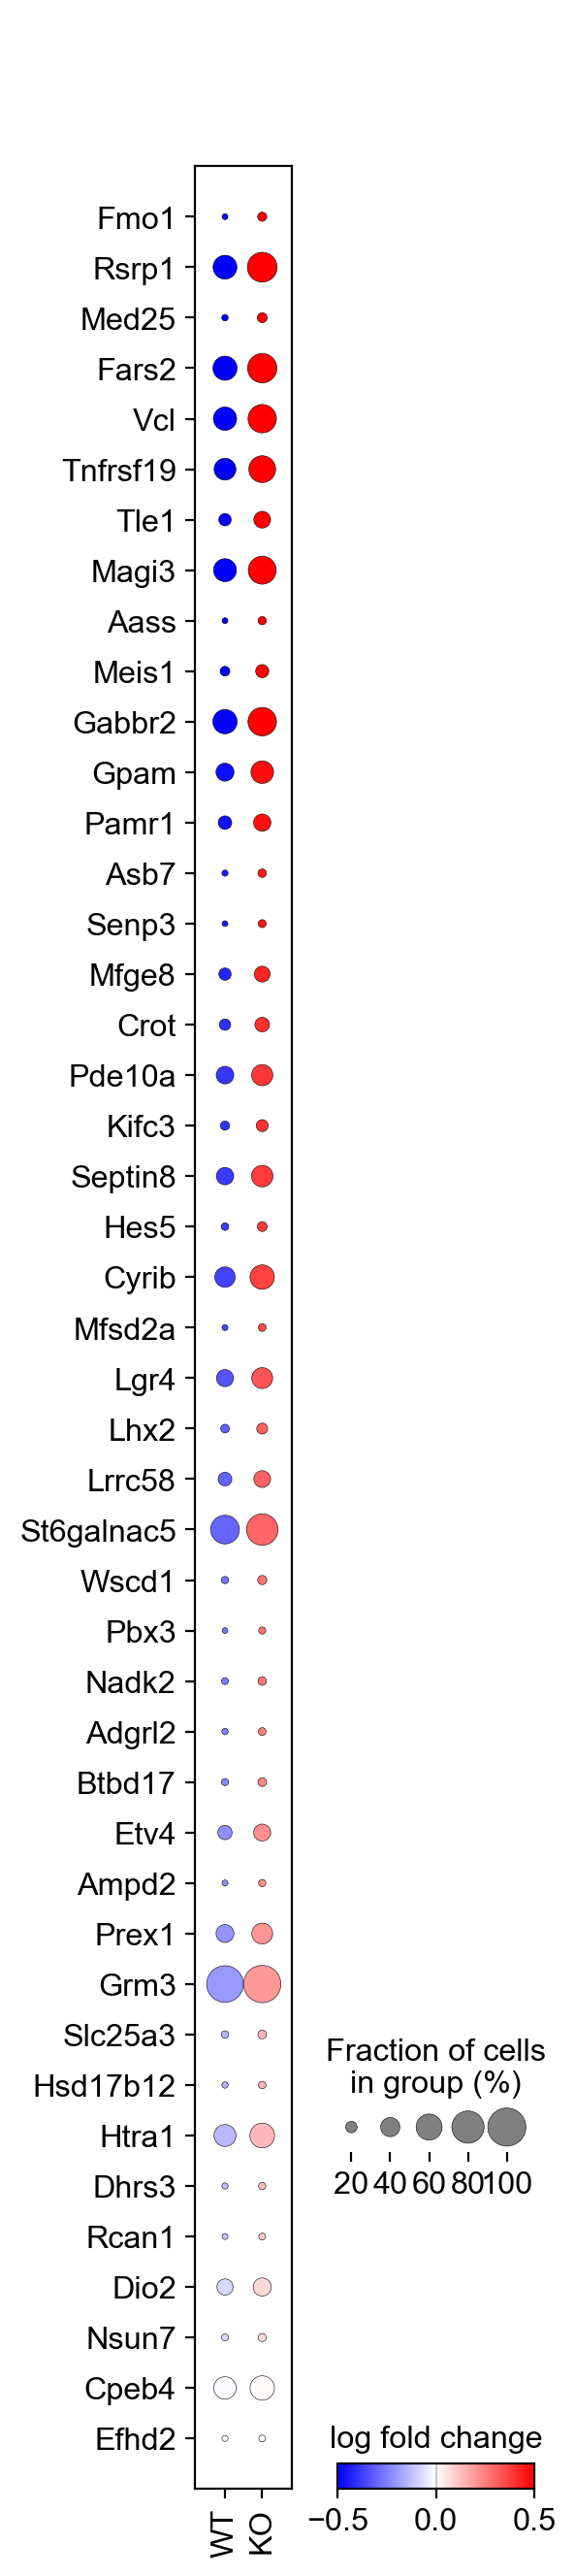

<Figure size 400x400 with 0 Axes>

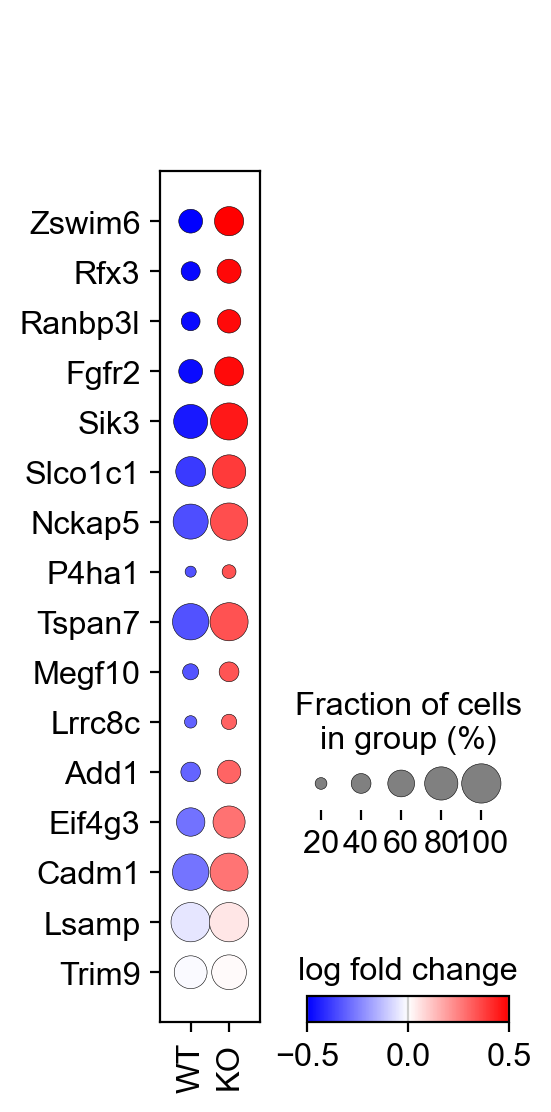

<Figure size 400x400 with 0 Axes>

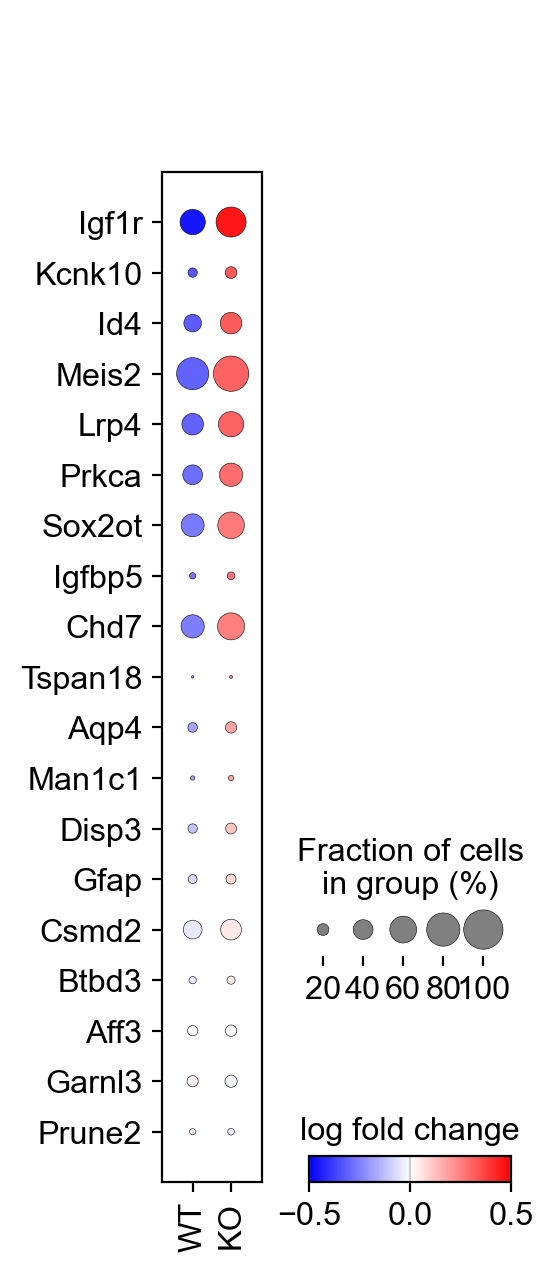

<Figure size 400x400 with 0 Axes>

In [11]:
import scanpy as sc
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
import seaborn as sns

# Read in the data
wilcox_astro = pd.read_csv("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/ASTRO_Wilcoxon_results_250106.csv")
zbtb20_layer = pd.read_csv("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/zbtb20_bound_layer_genes.csv")

zbtb20_upper = zbtb20_layer[(zbtb20_layer['layer'] == 'upper')]
upper_genes = zbtb20_upper['gene']
upper_unsorted = wilcox_astro[wilcox_astro['KO_n'].isin(upper_genes)][['KO_n', 'KO_l']]
upper_sorted = upper_unsorted.sort_values(by='KO_l', ascending = False)
upper_genes = upper_sorted['KO_n']

zbtb20_mid = zbtb20_layer[(zbtb20_layer['layer'] == 'mid') | (zbtb20_layer['layer'] == 'upper_mid')]
mid_genes = zbtb20_mid['gene']
mid_unsorted = wilcox_astro[wilcox_astro['KO_n'].isin(mid_genes)][['KO_n', 'KO_l']]
mid_sorted = mid_unsorted.sort_values(by='KO_l', ascending = False)
mid_genes = mid_sorted['KO_n']

zbtb20_deep_WM = zbtb20_layer[(zbtb20_layer['layer'] == 'deep') | (zbtb20_layer['layer'] == 'deep_WM') | (zbtb20_layer['layer'] == 'WM')]
deep_genes = zbtb20_deep_WM['gene']
deep_unsorted = wilcox_astro[wilcox_astro['KO_n'].isin(deep_genes)][['KO_n', 'KO_l']]
deep_sorted = deep_unsorted.sort_values(by='KO_l', ascending = False)
deep_genes = deep_sorted['KO_n']

gene_sets = {
    "Upper": upper_genes,
    "Mid": mid_genes,
    "Deep": deep_genes
}
clusters = ['Upper', 'Mid', 'Deep']

# Define the directory to save the UMAP plots
save_dir = 'C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/dotplots_scvi_p28/'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

# Convert 'cluster_id' to categorical type (if not already)
adata_astro.obs["condition"] = adata_astro.obs["condition"].astype('category')

# Reorder the categories in 'cluster_id' so that 'Upper' comes first
genotype_order = ["WT", "KO"]
adata_astro.obs["condition"] = adata_astro.obs["condition"].cat.reorder_categories(genotype_order)

sc.tl.rank_genes_groups(adata_astro, groupby="condition", method="wilcoxon")

for cluster in clusters:
    sc.pl.rank_genes_groups_dotplot(
        adata_astro, groupby="condition", 
        groups = [cluster],
        #standard_scale="var", 
        var_names = gene_sets[cluster], 
        dot_max = 1,
        #n_genes = 15,
        values_to_plot="logfoldchanges", 
        cmap = 'bwr', swap_axes = True, dendrogram = False, show = False, #figsize = (3, 5),
        vmin=-0.5, vmax=0.5
    )
    # Save the plot to the specified directory
    plot_filename = f"KOvWT_{cluster}_enriched_dotplot_astro.png"  # Generate a unique filename for each cluster
    save_path = os.path.join(save_dir, plot_filename)  # Full path to save the plot
    plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution
    
    # Show the plot
    plt.show()
    
    # Optionally, clear the current figure to avoid overlap in the next loop
    plt.clf()